In [1]:


# Import all the libraries used in this notebook
# from pvlib.solarposition import get_solarposition
import datetime
import os
from glob import glob
from os.path import join

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

import plotly
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objs as go
from  plotly.graph_objs import *
import plotly.io as pio
pio.renderers.default = 'iframe'

print(os.environ["CONDA_DEFAULT_ENV"])  # Check the name of the current Conda environment

/glade/work/dettling/conda-envs/plotlyenv


In [3]:
## MVCO QC file post-processed  

In [2]:
# mvco= pd.read_csv('mvco_mlsl_qc.csv')
flip = pd.read_csv("/glade/campaign/ral/wsap/oracleMLSL/data/flip_mlsl.csv")

flip["Time"] = pd.to_datetime(flip["Time"])
flip.index = flip["Time"]
print(len(flip.columns))
print(len(flip.index))
for col in flip.columns:
    print(col)

32
3311
Time
GHI:0_m:W_m-2
pressure:0_m:hPa
pressure:12.35_m:hPa
water_surface_temperature:0_m:K
temperature:12.35_m:K
potential_temperature:12.35_m:K
potential_temperature:0_m:K
dPotTemp_dz:12.35_m:K_m-1
specific_humidity:12.35_m:g_Kg-1
relative_humidity:12.35_m:%
mixing_ratio:0_m:g_kg-1
mixing_ratio:12.35_m:g_kg-1
dMixingRatio_dz:12.35_m:g_kg-1_m-1
skin_virtual_potential_temperature:0_m:K
wave_phase_speed:0_m:m_s-1
wave_height:0_m:m
wave_period:0_m:s
wind_speed:12.35_m:m_s-1
dSpeed_dz:12.35_m:s-1
wind_direction:?_m:degrees
u_wind:12.35_m:m_s-1
v_wind:12.35_m:m_s-1
bulk_richardson:12.35_m:none
FLIP_filtered_sensible_heat_flux:13.73_m:W/m2
heat_flux_raw:13.73_m:W_m-2
heat_flux:13.73_m:K_m_s-1
momentum_flux:13.73_m:m2_s-2
friction_velocity:13.73_m:m_s-1
surface_roughness_drennan:0_m:m
MOST_momentum_flux:13.73_m:m2_s-2
MOST_heat_flux:13.73_m:K_m_s-1


In [3]:
#
# Define this time series layout once, will use again in time series plots in rest of notebook
#
timeSeriesLayout = dict(
    title="Time Series with Rangeslider",
    xaxis=dict(
        rangeselector=dict(
            buttons=list(
                [
                    dict(count=1, label="1d", step="day", stepmode="forward"),
                    dict(count=7, label="1w", step="week", stepmode="forward"),
                    dict(count=30, label="1m", step="month", stepmode="forward"),
                    dict(step="all"),
                ]
            )
        ),
        rangeslider=dict(),
        type="date",
    ),
    width=1200,  # Custom width in pixels
    height=800,  # Custom height in pixels
)

layout = timeSeriesLayout
   
def drawTraces(*args):
    data = [*args]
    plotly.offline.iplot(data, filename="basic-line-plot")
    layout = timeSeriesLayout


In [4]:
traceaa = go.Scatter(
    x=flip.index,
    y=flip["heat_flux_raw:13.73_m:W_m-2"].where(np.fabs(flip["heat_flux_raw:13.73_m:W_m-2"]) < .5),
    name="heat_flux_raw:13.73_m:W_m-2",
    line=dict(color="cyan"),
    connectgaps=False,
    opacity=0.5,
)
tracea = go.Scatter(
    x=flip.index,
    y=flip["heat_flux:13.73_m:K_m_s-1"].where(np.fabs(flip["heat_flux:13.73_m:K_m_s-1"]) < .5),
    name="heat_flux:13.73_m:K_m_s-1",
    line=dict(color="purple"),
    connectgaps=False,
    opacity=0.5,
)
traceb = go.Scatter(
    x=flip.index,
    y=flip["MOST_heat_flux:13.73_m:K_m_s-1"],
    name="MOST_heat_flux:13.73_m:K_m_s-1",
    line=dict(color="red"),
    connectgaps=False,
    opacity=0.5,
)

drawTraces(*[ tracea, traceb])

In [5]:
tracec = go.Scatter(
    x=flip.index,
    y=flip["momentum_flux:13.73_m:m2_s-2"],
    name="momentum_flux:13.73_m:m2_s-2",
    line=dict(color="purple"),
    connectgaps=False,
    opacity=0.5,
)
traced = go.Scatter(
    x=flip.index,
    y=flip["MOST_momentum_flux:13.73_m:m2_s-2"],
    name="MOST_momentum_flux:13.73_m:m2_s-2",
    line=dict(color="red"),
    connectgaps=False,
    opacity=0.5,
)

drawTraces(*[tracec, traced])

In [6]:
tracec = go.Scatter(
    x=flip.index,
    y=flip['wave_phase_speed:0_m:m_s-1'],
    name='wave_phase_speed:0_m:m_s-1',
    line=dict(color="purple"),
    connectgaps=False,
    opacity=0.5,
)
drawTraces(*[tracec])

In [7]:
tracec = go.Scatter(
    x=flip.index,
    y=flip['wave_height:0_m:m'],
    name='wave_height:0_m:m',
    line=dict(color="purple"),
    connectgaps=False,
    opacity=0.5,
)
drawTraces(*[tracec])

In [8]:
tracec = go.Scatter(
    x=flip.index,
    y=flip['wind_speed:12.35_m:m_s-1'],
    name='wind_speed:12.35_m:m_s-1',
    line=dict(color="purple"),
    connectgaps=False,
    opacity=0.5,
)
drawTraces(*[tracec])

In [9]:
tracec = go.Scatter(
    x=flip.index,
    y=flip['pressure:0_m:hPa'],
    name='P0',
    line=dict(color="purple"),
    connectgaps=False,
    opacity=0.5,
)

traced = go.Scatter(
    x=flip.index,
    y=flip['pressure:12.35_m:hPa'],
    name='P12',
    line=dict(color="red"),
    connectgaps=False,
    opacity=0.5,
)


drawTraces(*[tracec, traced])

In [10]:
tracec = go.Scatter(
    x=flip.index,
    y=flip['skin_virtual_potential_temperature:0_m:K'],
    name='skin_virtual_potential_temperature:0_m:K',
    line=dict(color="purple"),
    connectgaps=False,
    opacity=0.5,
)


drawTraces(*[tracec])

In [11]:

tracec = go.Scatter(
    x=flip.index,
    y=flip['mixing_ratio:0_m:g_kg-1'],
    name='mixing_ratio:0_m:g_kg-1',
    line=dict(color="purple"),
    connectgaps=False,
    opacity=0.5,
)

traced = go.Scatter(
    x=flip.index,
    y=flip['mixing_ratio:12.35_m:g_kg-1'],
    name='mixing_ratio:12.35_m:g_kg-1',
    line=dict(color="green"),
    connectgaps=False,
    opacity=0.5,
)
drawTraces(*[tracec, traced])

In [12]:
tracec = go.Scatter(
    x=flip.index,
    y=flip['relative_humidity:12.35_m:%'],
    name='relative_humidity:12.35:%',
    line=dict(color="red"),
    connectgaps=False,
    opacity=0.5,
)
drawTraces(*[tracec])

In [13]:
tracec = go.Scatter(
    x=flip.index,
    y=flip['water_surface_temperature:0_m:K'],
    name='water_surface_temperature:0_m:K',
    line=dict(color="red"),
    connectgaps=False,
    opacity=0.5,
)

traced = go.Scatter(
    x=flip.index,
    y=flip['skin_virtual_potential_temperature:0_m:K'],
    name='skin_virtual_potential_temperature:0_m:K',
    line=dict(color="purple"),
    connectgaps=False,
    opacity=0.5,
)
tracee = go.Scatter(
    x=flip.index,
    y=flip['potential_temperature:12.35_m:K'],
    name='potential_temperature:12.35_m:K',
    line=dict(color="green"),
    connectgaps=False,
    opacity=0.5,
)
tracef = go.Scatter(
    x=flip.index,
    y=flip['potential_temperature:0_m:K'],
    name='potential_temperature:0_m:K',
    line=dict(color="orange"),
    connectgaps=False,
    opacity=0.5,
)
drawTraces(*[tracec, traced, tracee, tracef])

In [14]:
tracec = go.Scatter(
    x=flip.index,
    y=flip['bulk_richardson:12.35_m:none'],
    name='bulk_richardson:12.35_m:none',
    line=dict(color="purple"),
    connectgaps=False,
    opacity=0.5,
)


drawTraces(*[tracec])

In [19]:

traceg = go.Scatter(
         x=flip.index,
         y=flip["pressure:0_m:hPa"],
         name= "pressure:0_m:hPa",
         line=dict(color="blue"),
         connectgaps=False,
         opacity=0.5,
)

# We dont know thi height for sure-- guessing there was a pressure sensor one of the booms
traceh =go.Scatter(
         x=flip.index,
         y=flip["pressure:12.35_m:hPa"],
         name= "pressure:12.35_m:hPa",
         line=dict(color="green"),
         connectgaps=False,
         opacity=0.5,
)
drawTraces(*[traceg, traceh])

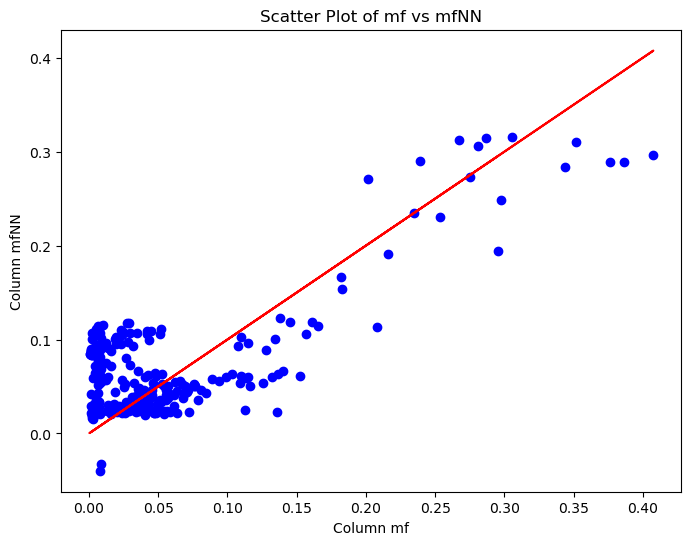

In [67]:
# This was a transfer learning exercise -- running MVCO models on flip data
dir1 = "/glade/campaign/ral/wsap/oracleMLSL/data/model_output/flip_sfc_xfer/model_QC_--kfold-0/surface_layer_model_predictions.csv"
df = pd.read_csv(dir1)
# Scatter plot of columns 'A' and 'B'
plt.figure(figsize=(8, 6))
plt.scatter(df['momentum_flux:13.73_m:m2_s-2'], df['momentum_flux-neural_network'], color='blue', marker='o')

# Add titles and labels
plt.title('Scatter Plot of mf vs mfNN')
plt.xlabel('Column mf')
plt.ylabel('Column mfNN')
plt.plot(df['momentum_flux:13.73_m:m2_s-2'],df['momentum_flux:13.73_m:m2_s-2'],c='r')

# Show the plot
plt.show()
#mvcoRaw.index = mvco["DateTime"]

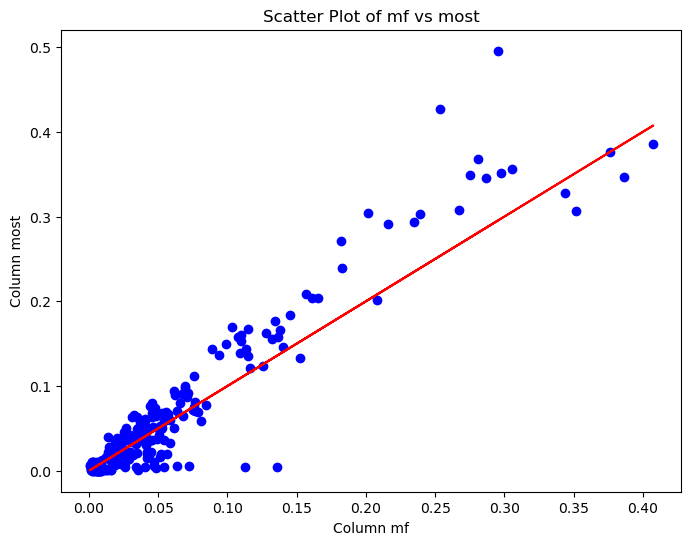

In [72]:
plt.figure(figsize=(8, 6))
plt.scatter(df['momentum_flux:13.73_m:m2_s-2'], df['MOST_momentum_flux:13.73_m:m2_s-2'], color='blue', marker='o')

# Add titles and labels
plt.title('Scatter Plot of mf vs most')
plt.xlabel('Column mf')
plt.ylabel('Column most')
plt.plot(df['momentum_flux:13.73_m:m2_s-2'],df['momentum_flux:13.73_m:m2_s-2'],c='r')

# Show the plot
plt.show()

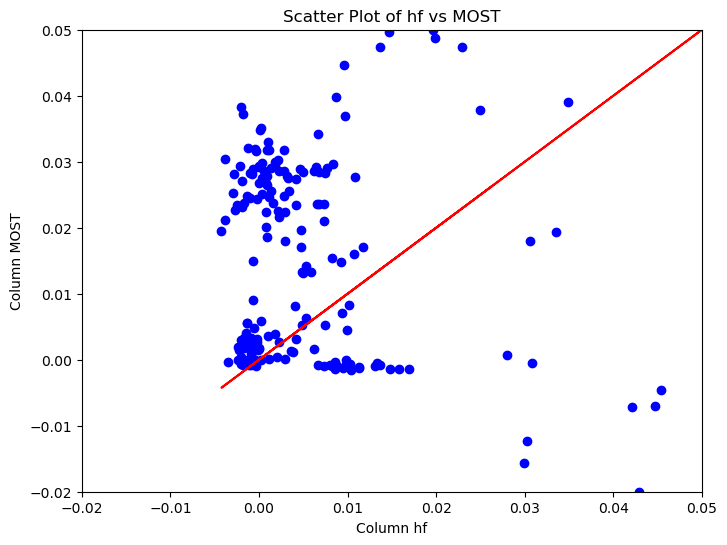

In [73]:
plt.figure(figsize=(8, 6))
plt.scatter(df['heat_flux:13.73_m:K_m_s-1'], df['MOST_heat_flux:13.73_m:K_m_s-1'], color='blue', marker='o')

# Add titles and labels
plt.title('Scatter Plot of hf vs MOST')
plt.xlabel('Column hf')
plt.ylabel('Column MOST')
plt.xlim(-0.02,.05)
plt.ylim(-0.02,.05)
plt.plot(df['heat_flux:13.73_m:K_m_s-1'],df['heat_flux:13.73_m:K_m_s-1'],c='r')
# Show the plot
plt.show()

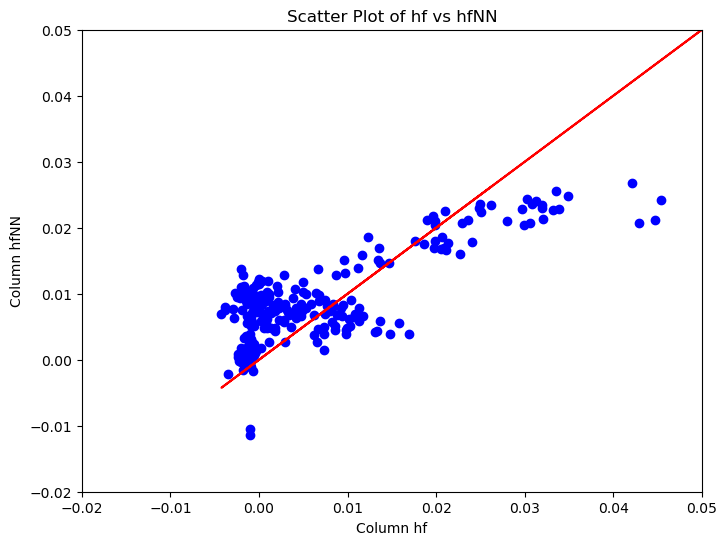

In [66]:
plt.figure(figsize=(8, 6))
plt.scatter(df['heat_flux:13.73_m:K_m_s-1'], df['heat_flux-neural_network'], color='blue', marker='o')

# Add titles and labels
plt.title('Scatter Plot of hf vs hfNN')
plt.xlabel('Column hf')
plt.ylabel('Column hfNN')
plt.xlim(-0.02,.05)
plt.ylim(-0.02,.05)
plt.plot(df['heat_flux:13.73_m:K_m_s-1'],df['heat_flux:13.73_m:K_m_s-1'],c='r')
# Show the plot
plt.show()

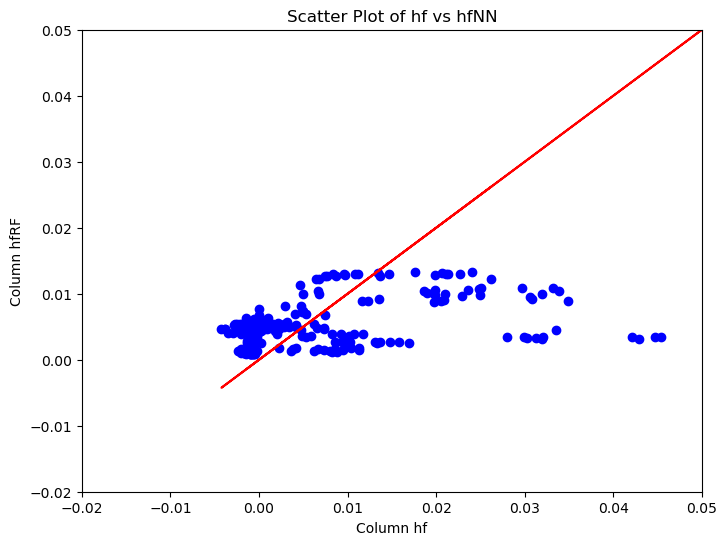

In [68]:
plt.figure(figsize=(8, 6))
plt.scatter(df['heat_flux:13.73_m:K_m_s-1'], df['heat_flux-random_forest'], color='blue', marker='o')

# Add titles and labels
plt.title('Scatter Plot of hf vs hfNN')
plt.xlabel('Column hf')
plt.ylabel('Column hfRF')
plt.xlim(-0.02,.05)
plt.ylim(-0.02,.05)
plt.plot(df['heat_flux:13.73_m:K_m_s-1'],df['heat_flux:13.73_m:K_m_s-1'],c='r')
# Show the plot
plt.show()

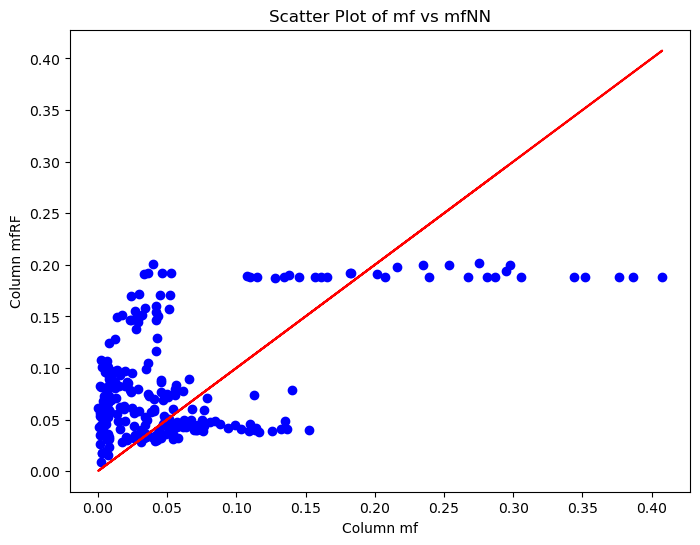

In [69]:
plt.figure(figsize=(8, 6))
plt.scatter(df['momentum_flux:13.73_m:m2_s-2'], df['momentum_flux-random_forest'], color='blue', marker='o')

# Add titles and labels
plt.title('Scatter Plot of mf vs mfNN')
plt.xlabel('Column mf')
plt.ylabel('Column mfRF')
plt.plot(df['momentum_flux:13.73_m:m2_s-2'],df['momentum_flux:13.73_m:m2_s-2'],c='r')

# Show the plot
plt.show()